# Brain Rot — Social Media & Mental Health

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelBinarizer , OrdinalEncoder 

## 2. Load & Inspect Data

In [2]:
data = pd.read_csv('Questionnaire  (Responses) - Form Responses 1.csv')
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [3]:
from sklearn.impute import SimpleImputer

In [4]:
df = data.copy()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 481 entries, 0 to 480
Data columns (total 21 columns):
 #   Column                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                --------------  -----  
 0   Timestamp                                                                                                             481 non-null    object 
 1   1. What is your age?                                                                                                  481 non-null    float64
 2   2. Gender                                                                                                             481 non-null    object 
 3   3. Relationship Status                                                                                                481 non-null    object 
 4   4. Occup

In [6]:
#
cols = df.columns
for i in cols:
    print(f"{i} =>,{df[i].unique()}")

Timestamp =>,['4/18/2022 19:18:47' '4/18/2022 19:19:28' '4/18/2022 19:25:59'
 '4/18/2022 19:29:43' '4/18/2022 19:33:31' '4/18/2022 19:33:48'
 '4/18/2022 19:36:12' '4/18/2022 19:36:17' '4/18/2022 19:39:36'
 '4/18/2022 19:41:34' '4/18/2022 19:44:06' '4/18/2022 19:44:10'
 '4/18/2022 19:56:24' '4/18/2022 19:57:04' '4/18/2022 19:59:08'
 '4/18/2022 20:15:31' '4/18/2022 20:15:38' '4/18/2022 20:21:09'
 '4/18/2022 20:22:02' '4/18/2022 20:28:03' '4/18/2022 20:31:53'
 '4/18/2022 20:32:59' '4/18/2022 20:33:36' '4/18/2022 20:35:50'
 '4/18/2022 20:36:42' '4/18/2022 20:38:00' '4/18/2022 20:38:08'
 '4/18/2022 20:40:47' '4/18/2022 20:42:23' '4/18/2022 20:45:33'
 '4/18/2022 20:49:37' '4/18/2022 20:50:39' '4/18/2022 20:52:05'
 '4/18/2022 20:53:37' '4/18/2022 20:54:50' '4/18/2022 20:55:44'
 '4/18/2022 20:55:48' '4/18/2022 21:02:52' '4/18/2022 21:22:13'
 '4/18/2022 21:24:02' '4/18/2022 21:32:37' '4/18/2022 21:42:54'
 '4/18/2022 21:48:07' '4/18/2022 21:48:34' '4/18/2022 21:49:19'
 '4/18/2022 21:50:33' '4/18

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()

Timestamp                                                                                                                0
1. What is your age?                                                                                                     0
2. Gender                                                                                                                0
3. Relationship Status                                                                                                   0
4. Occupation Status                                                                                                     0
5. What type of organizations are you affiliated with?                                                                  30
6. Do you use social media?                                                                                              0
7. What social media platforms do you commonly use?                                                                      0
8. What is the a

In [9]:
df.head()

,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,10. How often do you get distracted by Social media when you are busy doing something?,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,3,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,3,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,2,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,2,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,5,4,4,5,5,3,3,3,4,4,1


In [10]:
df["5. What type of organizations are you affiliated with?"].value_counts()

5. What type of organizations are you affiliated with?
University                        239
Private                            60
School                             44
Company                            30
University, Company                19
University, Private                16
School, University                  9
Company, Private                    7
Goverment                           6
University, Company, Private        5
School, University, Private         4
University, N/A                     3
University, Goverment               2
School, Company                     2
School, N/A                         2
School, Private                     1
University, Goverment, Private      1
University, Company, Goverment      1
Name: count, dtype: int64

In [11]:
df.drop(columns=['Timestamp'],inplace=True)

In [12]:
df[(df['4. Occupation Status'].notnull()) & (df['5. What type of organizations are you affiliated with?'].isnull())]


,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,10. How often do you get distracted by Social media when you are busy doing something?,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
17,25.0,Male,Single,School Student,NaN,Yes,"Facebook, Instagram, YouTube, Reddit",Between 4 and 5 hours,5,5,4,4,3,3,1,4,2,2,2,2
24,23.0,Male,Single,University Student,NaN,Yes,"Facebook, Twitter, YouTube, Discord",Between 3 and 4 hours,3,3,5,5,5,5,4,1,3,3,5,5
42,56.0,Female,Married,Retired,NaN,Yes,YouTube,Between 1 and 2 hours,1,1,1,1,3,1,1,3,1,2,3,1
47,17.0,Female,Single,School Student,NaN,Yes,"Instagram, YouTube, Reddit, Pinterest",Between 3 and 4 hours,4,3,1,3,5,3,4,2,1,3,5,1
63,25.0,Male,Single,Salaried Worker,NaN,Yes,Reddit,Between 1 and 2 hours,3,1,1,3,2,4,1,3,1,5,1,5
64,19.0,Female,Single,University Student,NaN,Yes,"Discord, Reddit",Between 2 and 3 hours,2,3,1,5,3,5,1,3,1,1,5,4
74,23.0,Female,Single,Retired,NaN,Yes,"Facebook, YouTube, Discord, Reddit",Between 4 and 5 hours,4,4,3,3,4,5,3,2,4,5,5,4
80,22.0,Male,Single,University Student,NaN,Yes,"Twitter, Instagram, YouTube, Snapchat, Discord...",Between 2 and 3 hours,4,4,4,5,5,5,3,3,1,4,4,5
85,24.0,NB,Single,Salaried Worker,NaN,Yes,"YouTube, Reddit",Between 2 and 3 hours,4,3,2,3,5,2,3,2,2,4,3,1
97,20.0,Male,Single,School Student,NaN,Yes,"YouTube, Reddit",More than 5 hours,4,2,1,2,1,1,2,2,1,4,3,2


In [13]:
df['5. What type of organizations are you affiliated with?'].isnull().sum()

np.int64(30)

In [14]:
df['4. Occupation Status'].unique()

array(['University Student', 'School Student', 'Salaried Worker',
       'Retired'], dtype=object)

## 3. Cleaning — Rename Columns

In [15]:
df.columns

Index(['1. What is your age?', '2. Gender', '3. Relationship Status',
       '4. Occupation Status',
       '5. What type of organizations are you affiliated with?',
       '6. Do you use social media?',
       '7. What social media platforms do you commonly use?',
       '8. What is the average time you spend on social media every day?',
       '9. How often do you find yourself using Social media without a specific purpose?',
       '10. How often do you get distracted by Social media when you are busy doing something?',
       '11. Do you feel restless if you haven't used Social media in a while?',
       '12. On a scale of 1 to 5, how easily distracted are you?',
       '13. On a scale of 1 to 5, how much are you bothered by worries?',
       '14. Do you find it difficult to concentrate on things?',
       '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?',
       '16. Following the previous question, how do you fe

In [16]:
df.rename(columns={
    '1. What is your age?': 'age',
    '2. Gender': 'gender',
    '3. Relationship Status': 'relationship',
    '4. Occupation Status': 'career',
    '5. What type of organizations are you affiliated with?': 'organization',
    '6. Do you use social media?': 'uses_social_media',
    '7. What social media platforms do you commonly use?': 'platforms',
    '8. What is the average time you spend on social media every day?': 'daily_time',
    '9. How often do you find yourself using Social media without a specific purpose?': 'aimless_use',
    '10. How often do you get distracted by Social media when you are busy doing something?': 'distracted_when_busy',
    "11. Do you feel restless if you haven't used Social media in a while?": 'restless_without',
    '12. On a scale of 1 to 5, how easily distracted are you?': 'distractibility',
    '13. On a scale of 1 to 5, how much are you bothered by worries?': 'worries',
    '14. Do you find it difficult to concentrate on things?': 'concentration_difficulty',
    '15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?': 'comparison',
    '16. Following the previous question, how do you feel about these comparisons, generally speaking?': 'comparison_feeling',
    '17. How often do you look to seek validation from features of social media?': 'seeks_validation',
    '18. How often do you feel depressed or down?': 'depression',
    '19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?': 'interest_fluctuation',
    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?': 'sleep_issues'
}, inplace=True)

In [17]:
df.head()

,age,gender,relationship,career,organization,uses_social_media,platforms,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,comparison_feeling,seeks_validation,depression,interest_fluctuation,sleep_issues
0,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,3,2,5,2,5,2,3,2,5,4,5
1,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,3,2,4,5,4,5,1,1,5,4,5
2,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,2,1,2,5,4,3,3,1,4,2,5
3,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,2,1,3,5,3,5,1,2,4,3,2
4,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,5,4,4,5,5,3,3,3,4,4,1


### Feature Descriptions

**age** — Respondent's age.

**gender** — Respondent's gender.

**relationship** — Relationship status (e.g., single, married, in a relationship).

**career** — Occupation status (e.g., student, employed, retired).

**organization** — Type of organization the respondent is affiliated with (e.g., university, private company, government).

**uses_social_media** — Whether the respondent uses social media at all.

**platforms** — Which social media platforms they commonly use (e.g., Facebook, Instagram, Twitter).

**daily_time** — Average time spent on social media per day.

**aimless_use** — How often they use social media without a specific purpose.

**distracted_when_busy** — How often social media distracts them while doing something else.

**restless_without** — Whether they feel restless when they haven't used social media for a while.

**distractibility** — Self-rated ease of getting distracted, on a 1–5 scale.

**worries** — How much they are bothered by worries, on a 1–5 scale.

**concentration_difficulty** — Whether they find it difficult to concentrate.

**comparison** — How often they compare themselves to successful people via social media, on a 1–5 scale.

**comparison_feeling** — How they generally feel about those comparisons.

**seeks_validation** — How often they seek validation from social media features (likes, comments, etc.).

**depression** — How often they feel depressed or down.

**interest_fluctuation** — How frequently their interest in daily activities fluctuates, on a 1–5 scale.

**sleep_issues** — How often they face sleep-related issues, on a 1–5 scale.

## 4. Encoding & Feature Engineering

In [18]:
# split combined values from social media columns commonly used.
df['gender'].value_counts()


gender
Female                 263
Male                   211
Nonbinary                1
Non-binary               1
NB                       1
unsure                   1
Trans                    1
Non binary               1
There are others???      1
Name: count, dtype: int64

In [19]:
df = df[df['gender'].isin(['Female', 'Male'])]

In [20]:
df['gender'].value_counts()

gender
Female    263
Male      211
Name: count, dtype: int64

In [21]:
df['relationship'].value_counts()

relationship
Single               280
Married              101
In a relationship     87
Divorced               6
Name: count, dtype: int64

In [22]:
df['career'].value_counts()

career
University Student    290
Salaried Worker       129
School Student         47
Retired                 8
Name: count, dtype: int64

In [23]:
df['uses_social_media'].value_counts()

uses_social_media
Yes    471
No       3
Name: count, dtype: int64

In [24]:
df['platforms'].value_counts()

platforms
Facebook, Instagram, YouTube                                                           35
Facebook, YouTube                                                                      30
Facebook, Instagram, YouTube, Snapchat                                                 27
Facebook, Instagram, YouTube, Snapchat, Discord                                        19
Facebook, Instagram, YouTube, Discord                                                  18
Facebook                                                                               18
Facebook, Instagram, YouTube, Pinterest                                                16
Facebook, Twitter, Instagram, YouTube                                                  14
Facebook, Twitter, Instagram, YouTube, Snapchat, Discord, Reddit, Pinterest, TikTok    11
Facebook, Instagram                                                                    10
Facebook, Instagram, YouTube, Snapchat, Pinterest                                       8


In [25]:
df['daily_time'].value_counts()

daily_time
More than 5 hours        112
Between 2 and 3 hours     99
Between 3 and 4 hours     93
Between 1 and 2 hours     70
Between 4 and 5 hours     66
Less than an Hour         34
Name: count, dtype: int64

In [26]:
in_order = [
    'Less than an Hour',
    'Between 1 and 2 hours',
    'Between 2 and 3 hours',
    'Between 3 and 4 hours',
    'Between 4 and 5 hours',
    'More than 5 hours'
]

orenc = OrdinalEncoder(categories=[in_order])
df['daily_time'] = orenc.fit_transform(df[['daily_time']])

df['daily_time'].unique()

array([2., 5., 3., 0., 1., 4.])

In [27]:
df['age'].unique()

array([21. , 22. , 20. , 24. , 23. , 25. , 28. , 34. , 26. , 35. , 18. ,
       19. , 56. , 65. , 17. , 40. , 33. , 55. , 27. , 14. , 38. , 32. ,
       30. , 16. , 48. , 47. , 50. , 49. , 51. , 46. , 36. , 37. , 45. ,
       42. , 31. , 91. , 15. , 29. , 43. , 26.7, 52. , 44. , 60. , 13. ,
       53. ])

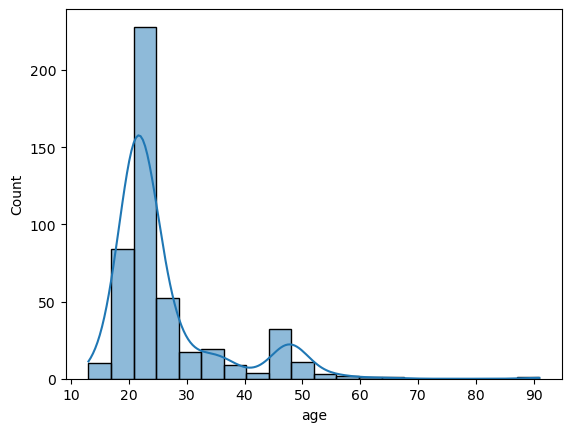

In [28]:
sns.histplot(data=df, x='age',bins=20,kde=True)
plt.show()

In [29]:
# gender label encoding
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
df['gender'] = lb.fit_transform(df['gender'])

In [30]:
lb.classes_

array(['Female', 'Male'], dtype=object)

In [31]:
df['gender'].unique()


array([1, 0])

In [32]:
lb.inverse_transform([1, 0])

array(['Male', 'Female'], dtype=object)

In [33]:
df.head(1)

,age,gender,relationship,career,organization,uses_social_media,platforms,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,comparison_feeling,seeks_validation,depression,interest_fluctuation,sleep_issues
0,21.0,1,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",2.0,5,3,2,5,2,5,2,3,2,5,4,5


In [34]:
# social media usage , label encoding
df['uses_social_media'] = lb.fit_transform(df['uses_social_media'])
lb.classes_

array(['No', 'Yes'], dtype=object)

In [35]:
df['uses_social_media'].unique()

array([1, 0])

In [36]:
lb.inverse_transform([1, 0])

array(['Yes', 'No'], dtype=object)

In [37]:
# one hot encoding for platforms
df['platforms'] = df['platforms'].str.replace(' ', '')
df = df.join(df['platforms'].str.get_dummies(sep=','))
df = df.drop(columns='platforms')

In [38]:
df.head(5)

,age,gender,relationship,career,organization,uses_social_media,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,comparison_feeling,seeks_validation,depression,interest_fluctuation,sleep_issues,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube
0,21.0,1,In a relationship,University Student,University,1,2.0,5,3,2,5,2,5,2,3,2,5,4,5,1,1,1,0,1,0,0,1,1
1,21.0,0,Single,University Student,University,1,5.0,4,3,2,4,5,4,5,1,1,5,4,5,1,1,1,0,1,0,0,1,1
2,21.0,0,Single,University Student,University,1,3.0,3,2,1,2,5,4,3,3,1,4,2,5,0,1,1,1,0,0,0,0,1
3,21.0,0,Single,University Student,University,1,5.0,4,2,1,3,5,3,5,1,2,4,3,2,0,1,1,0,0,0,0,0,0
4,21.0,0,Single,University Student,University,1,2.0,3,5,4,4,5,5,3,3,3,4,4,1,0,1,1,0,0,0,0,0,1


In [39]:
df['relationship'] = lb.fit_transform(df['relationship'])
lb.classes_

array(['Divorced', 'In a relationship', 'Married', 'Single'], dtype=object)

In [40]:
df['relationship'].unique()

array([1, 3, 2, 0])

In [41]:
df['relationship'] = lb.inverse_transform(df['relationship'])
df = df.join(pd.get_dummies(df['relationship'], prefix='rel', dtype=int))
df = df.drop(columns='relationship')

In [42]:
df.head()

,age,gender,career,organization,uses_social_media,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,comparison_feeling,seeks_validation,depression,interest_fluctuation,sleep_issues,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube,rel_Divorced,rel_In a relationship,rel_Married,rel_Single
0,21.0,1,University Student,University,1,2.0,5,3,2,5,2,5,2,3,2,5,4,5,1,1,1,0,1,0,0,1,1,0,1,0,0
1,21.0,0,University Student,University,1,5.0,4,3,2,4,5,4,5,1,1,5,4,5,1,1,1,0,1,0,0,1,1,0,0,0,1
2,21.0,0,University Student,University,1,3.0,3,2,1,2,5,4,3,3,1,4,2,5,0,1,1,1,0,0,0,0,1,0,0,0,1
3,21.0,0,University Student,University,1,5.0,4,2,1,3,5,3,5,1,2,4,3,2,0,1,1,0,0,0,0,0,0,0,0,0,1
4,21.0,0,University Student,University,1,2.0,3,5,4,4,5,5,3,3,3,4,4,1,0,1,1,0,0,0,0,0,1,0,0,0,1


In [43]:
df['career'].unique()

array(['University Student', 'School Student', 'Salaried Worker',
       'Retired'], dtype=object)

In [44]:
# fixing career values and normalize it
df['career'] = df['career'].map({
    'University Student': 'Student',
    'School Student': 'Student',
    'Salaried Worker': 'Worker',
    'Retired': 'Retired'
})

df['career'].unique()

array(['Student', 'Worker', 'Retired'], dtype=object)

In [45]:
df.sample(5)

,age,gender,career,organization,uses_social_media,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,comparison_feeling,seeks_validation,depression,interest_fluctuation,sleep_issues,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube,rel_Divorced,rel_In a relationship,rel_Married,rel_Single
354,19.0,1,Student,Private,1,4.0,3,3,2,2,3,2,2,1,3,2,2,2,1,1,1,0,1,1,1,0,1,0,0,0,1
261,21.0,0,Student,University,1,2.0,3,3,2,3,5,4,3,3,3,5,5,4,1,1,1,0,0,1,1,0,1,0,1,0,0
464,14.0,1,Student,School,1,2.0,3,4,2,4,3,2,1,3,1,2,3,1,1,0,1,0,0,0,0,0,0,0,0,0,1
478,29.0,0,Worker,University,1,2.0,3,3,4,3,2,3,3,3,4,2,2,2,0,1,0,0,0,0,0,0,1,0,0,1,0
81,21.0,1,Student,University,1,5.0,4,4,2,5,4,4,3,3,2,1,5,4,1,1,1,1,1,1,0,0,1,0,0,0,1


In [46]:
df = df.join(pd.get_dummies(df['career'], dtype=int))
df = df.drop(columns='career')
df.sample(5)

,age,gender,organization,uses_social_media,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,comparison_feeling,seeks_validation,depression,interest_fluctuation,sleep_issues,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube,rel_Divorced,rel_In a relationship,rel_Married,rel_Single,Retired,Student,Worker
274,21.0,1,University,1,2.0,4,4,4,5,5,4,4,2,3,3,4,3,1,1,1,0,1,0,0,1,1,0,0,0,1,0,1,0
462,28.0,0,Private,1,2.0,5,4,1,5,4,5,2,2,2,5,5,2,0,1,1,1,0,0,0,0,1,0,0,1,0,0,0,1
436,22.0,0,University,1,5.0,1,5,2,3,5,2,1,2,2,3,3,4,0,1,1,0,0,1,0,0,0,0,1,0,0,0,1,0
381,20.0,1,"School, University",1,3.0,4,3,2,3,5,5,5,5,5,5,5,1,1,0,1,1,1,0,0,0,1,0,0,0,1,0,1,0
333,25.0,0,"University, Company, Private",1,5.0,5,5,4,4,5,1,2,2,3,5,2,4,0,1,1,1,0,0,1,0,1,0,0,0,1,0,1,0


In [47]:
# drop organizationi col , it doesn't serve the dataset we already have career.
df.drop(columns=['organization'],inplace=True)

In [48]:
df.sample(5)

,age,gender,uses_social_media,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,comparison_feeling,seeks_validation,depression,interest_fluctuation,sleep_issues,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube,rel_Divorced,rel_In a relationship,rel_Married,rel_Single,Retired,Student,Worker
200,21.0,0,1,1.0,3,3,2,5,4,5,4,2,2,2,3,2,1,1,1,0,0,1,0,1,1,0,0,0,1,0,1,0
211,21.0,1,1,5.0,5,1,1,1,1,1,1,3,1,1,1,1,1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0
58,22.0,0,1,2.0,4,5,2,4,4,4,3,3,4,5,4,2,1,1,1,1,1,1,1,1,1,0,0,1,0,0,1,0
222,21.0,0,1,1.0,4,3,1,3,4,3,5,2,3,3,4,3,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0
275,21.0,0,1,3.0,5,4,2,5,5,4,4,3,3,5,5,5,1,1,1,1,0,1,1,0,1,0,1,0,0,0,1,0


In [49]:
df['age'].sort_values(ascending=False)

256    91.0
46     65.0
453    60.0
42     56.0
456    56.0
53     55.0
480    53.0
401    52.0
138    51.0
457    51.0
134    50.0
139    50.0
130    50.0
460    50.0
219    50.0
153    50.0
454    49.0
135    49.0
149    49.0
166    48.0
110    48.0
163    48.0
168    48.0
137    48.0
162    48.0
120    48.0
161    48.0
154    48.0
181    48.0
107    48.0
148    48.0
216    48.0
136    47.0
165    47.0
145    47.0
131    47.0
164    47.0
140    47.0
156    47.0
182    47.0
147    47.0
152    47.0
175    47.0
112    47.0
186    47.0
187    47.0
113    47.0
109    47.0
143    46.0
228    46.0
185    45.0
403    44.0
404    44.0
346    43.0
195    42.0
48     40.0
142    40.0
73     38.0
197    38.0
133    38.0
158    37.0
180    37.0
351    37.0
217    37.0
260    36.0
236    36.0
157    36.0
27     35.0
25     35.0
472    35.0
176    35.0
196    35.0
406    35.0
31     35.0
355    35.0
115    34.0
455    34.0
19     34.0
248    34.0
250    34.0
212    34.0
70     33.0
49     33.0
199 

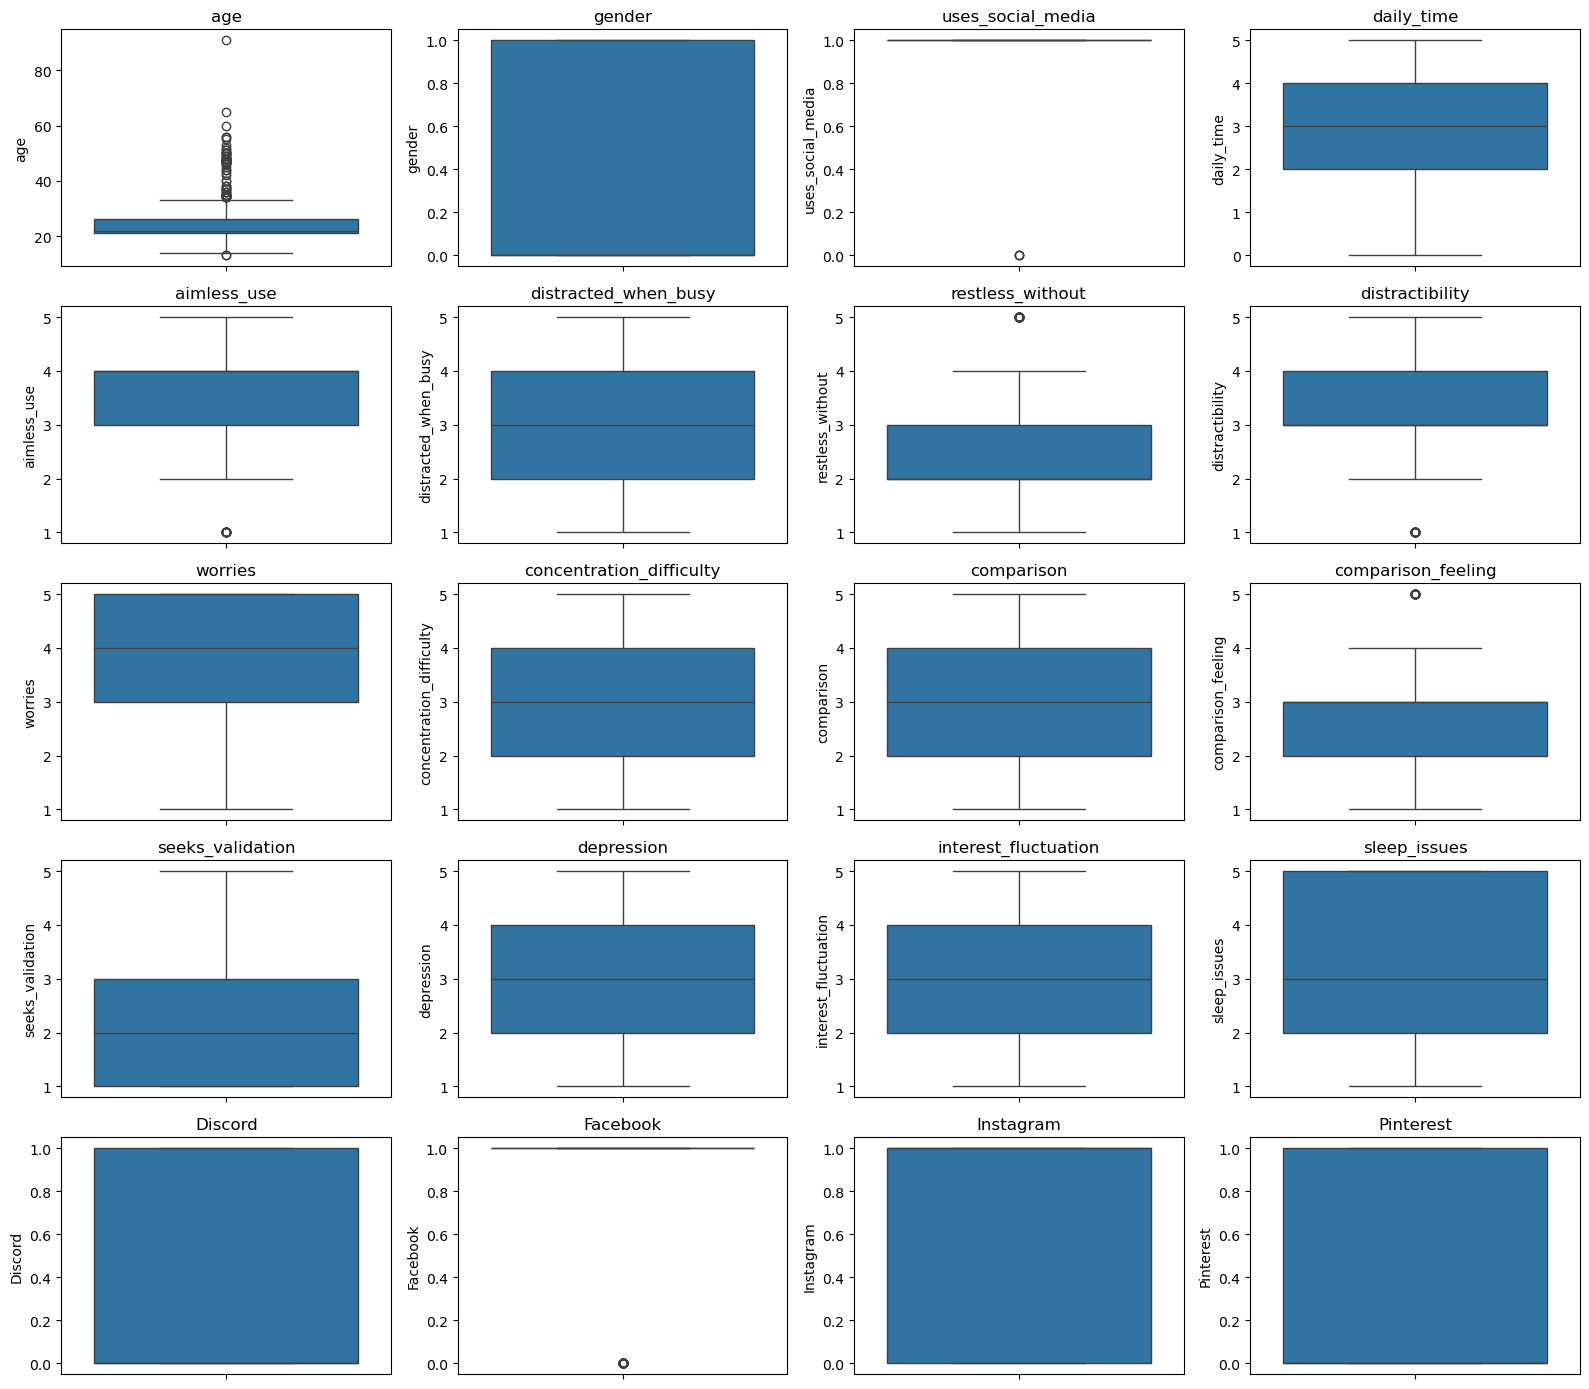

In [50]:
num_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots(5, 4, figsize=(16, 14))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [51]:
df.describe()

,age,gender,uses_social_media,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,comparison_feeling,seeks_validation,depression,interest_fluctuation,sleep_issues,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube,rel_Divorced,rel_In a relationship,rel_Married,rel_Single,Retired,Student,Worker
count,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000,474.000000
mean,26.117511,0.445148,0.993671,2.892405,3.550633,3.318565,2.573840,3.337553,3.554852,3.238397,2.829114,2.770042,2.451477,3.248945,3.170886,3.210970,0.413502,0.852321,0.746835,0.303797,0.257384,0.375527,0.189873,0.270042,0.856540,0.012658,0.183544,0.213080,0.590717,0.016878,0.710970,0.272152
std,9.767589,0.497507,0.079387,1.588484,1.098995,1.326982,1.250721,1.175860,1.278439,1.350015,1.410590,1.056476,1.243490,1.312345,1.256828,1.453219,0.492982,0.355157,0.435284,0.460382,0.437655,0.484770,0.392615,0.444450,0.350912,0.111913,0.387521,0.409916,0.492221,0.128949,0.453791,0.445538
min,13.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,1.000000,2.000000,3.000000,2.000000,2.000000,3.000000,3.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,22.000000,0.000000,1.000000,3.000000,4.000000,3.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
75%,26.000000,1.000000,1.000000,4.000000,4.000000,4.000000,3.000000,4.000000,5.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,91.000000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [52]:
df = df.drop(df[df['age'] > 80].index)
df[df['age'] > 80]

,age,gender,uses_social_media,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,comparison_feeling,seeks_validation,depression,interest_fluctuation,sleep_issues,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube,rel_Divorced,rel_In a relationship,rel_Married,rel_Single,Retired,Student,Worker


In [53]:
df[df['age'] > 50]

,age,gender,uses_social_media,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,comparison_feeling,seeks_validation,depression,interest_fluctuation,sleep_issues,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube,rel_Divorced,rel_In a relationship,rel_Married,rel_Single,Retired,Student,Worker
42,56.0,0,1,1.0,1,1,1,1,3,1,1,3,1,2,3,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0
46,65.0,1,1,3.0,5,3,2,2,2,1,3,4,3,1,3,2,0,1,0,0,0,0,0,0,1,0,0,1,0,1,0,0
53,55.0,1,1,1.0,3,2,1,3,2,1,1,3,1,1,2,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
138,51.0,1,1,1.0,4,3,2,3,3,4,3,3,3,3,3,3,0,1,1,1,0,1,0,1,1,0,0,1,0,0,0,1
401,52.0,1,1,1.0,2,2,3,3,3,2,3,2,2,3,2,4,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1
453,60.0,1,1,2.0,1,2,1,1,1,1,3,3,3,1,1,1,0,1,0,0,0,0,0,0,1,0,0,0,1,1,0,0
456,56.0,1,1,2.0,1,1,1,1,1,1,1,1,1,1,1,2,0,1,0,1,0,0,0,1,1,0,0,1,0,0,0,1
457,51.0,1,1,1.0,3,2,3,4,2,3,4,3,3,2,2,4,0,1,1,0,0,0,0,1,1,0,0,1,0,0,0,1
480,53.0,1,1,0.0,2,3,1,3,1,1,3,3,2,2,2,3,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1


In [54]:
# feature engineering , creating new feature age group
bins = [0, 18, 30, 45, 100]
labels = ['<18', '18-29', '30-44', '45+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [55]:
df.sample(5)

,age,gender,uses_social_media,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,comparison_feeling,seeks_validation,depression,interest_fluctuation,sleep_issues,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube,rel_Divorced,rel_In a relationship,rel_Married,rel_Single,Retired,Student,Worker,age_group
321,21.0,0,1,5.0,3,3,2,2,4,4,4,3,3,4,2,4,1,1,1,1,0,1,0,0,1,0,0,0,1,0,1,0,18-29
351,37.0,0,1,1.0,2,2,1,3,3,2,2,3,1,3,3,4,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,30-44
401,52.0,1,1,1.0,2,2,3,3,3,2,3,2,2,3,2,4,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,45+
90,22.0,1,1,2.0,3,5,2,4,4,4,2,3,2,4,4,3,0,1,1,0,0,1,0,0,1,0,1,0,0,0,1,0,18-29
381,20.0,1,1,3.0,4,3,2,3,5,5,5,5,5,5,5,1,1,0,1,1,1,0,0,0,1,0,0,0,1,0,1,0,18-29


In [56]:
df['age_group'] = lb.fit_transform(df['age_group'])

In [57]:
lb.classes_

array(['18-29', '30-44', '45+', '<18'], dtype=object)

In [58]:
df['age_group'] = lb.inverse_transform(df['age_group'])

In [59]:
lb.classes_

array(['18-29', '30-44', '45+', '<18'], dtype=object)

In [60]:
df.sample(5)

,age,gender,uses_social_media,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,comparison_feeling,seeks_validation,depression,interest_fluctuation,sleep_issues,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube,rel_Divorced,rel_In a relationship,rel_Married,rel_Single,Retired,Student,Worker,age_group
101,22.0,1,1,1.0,5,4,3,4,4,2,1,1,1,5,3,5,1,1,1,1,1,1,0,1,1,0,1,0,0,0,1,0,18-29
221,23.0,0,1,2.0,4,4,1,3,2,2,1,2,1,2,4,1,1,1,1,1,0,1,0,1,1,0,0,0,1,0,1,0,18-29
210,31.0,1,1,2.0,3,3,3,3,4,3,4,4,4,3,3,2,1,1,1,0,0,0,0,0,1,0,0,0,1,0,0,1,30-44
231,20.0,0,1,0.0,3,1,1,1,2,2,5,1,2,1,3,1,0,1,1,0,0,0,0,0,1,0,0,0,1,0,1,0,18-29
164,47.0,1,1,2.0,3,2,3,5,5,5,2,5,2,3,2,4,0,0,1,0,1,0,1,1,1,0,0,1,0,0,0,1,45+


In [61]:
# change the values to be more meaningful :
df['age_group'] = df['age_group'].map({
    '<18': 'Teens',
    '18-29': 'Young Adults',
    '30-44': 'Adults',
    '45+': 'Older Adults'
})

In [62]:
df['age_group'].unique()

array(['Young Adults', 'Adults', 'Teens', 'Older Adults'], dtype=object)

In [63]:
# ordinal encoding for age_group
categories=['Older Adults', 'Adults', 'Young Adults', 'Teens']
orenc = OrdinalEncoder(categories=[categories])

df['age_group'] = orenc.fit_transform(df[['age_group']]).astype(int)

df['age_group'].unique()

array([2, 1, 3, 0])

In [64]:
df.sample(5)

,age,gender,uses_social_media,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,comparison_feeling,seeks_validation,depression,interest_fluctuation,sleep_issues,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube,rel_Divorced,rel_In a relationship,rel_Married,rel_Single,Retired,Student,Worker,age_group
244,21.0,0,1,1.0,3,5,2,4,2,2,1,4,2,3,2,3,1,1,1,0,1,1,0,0,1,0,0,0,1,0,1,0,2
211,21.0,1,1,5.0,5,1,1,1,1,1,1,3,1,1,1,1,1,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,2
83,21.0,0,1,4.0,3,5,5,5,3,5,4,4,3,4,5,5,0,1,1,1,0,0,0,0,1,0,1,0,0,0,1,0,2
41,21.0,0,1,3.0,3,5,2,3,3,3,3,4,2,4,2,2,0,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,2
309,20.0,0,1,3.0,3,3,2,2,4,2,2,3,2,2,3,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,1,0,2


### Cleaning & encoding complete

The cleaned frame is saved to `brain_rot_cleaned.csv` and reloaded below for modeling.

In [65]:
#df.to_csv('brain_rot_cleaned.csv')

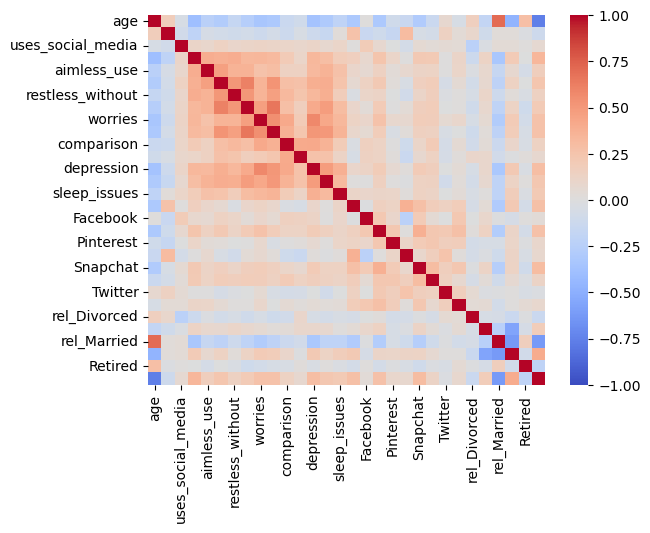

In [67]:
corr = df.corr()

sns.heatmap(corr,vmin=-1,vmax=1,cmap='coolwarm',)
plt.show()

In [66]:
df = pd.read_csv('brain_rot_cleaned.csv').drop(columns=['Unnamed: 0'])

# drop these three, for three different reasons:
df = df.drop(columns=['comparison_feeling',  # no shared variance, alpha 0.852 -> 0.863
                      'age_group',           # duplicate of age, and uneven bins
                      'Worker'])             # r = -0.96 with Student, redundant

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 473 entries, 0 to 472
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       473 non-null    float64
 1   gender                    473 non-null    int64  
 2   uses_social_media         473 non-null    int64  
 3   daily_time                473 non-null    float64
 4   aimless_use               473 non-null    int64  
 5   distracted_when_busy      473 non-null    int64  
 6   restless_without          473 non-null    int64  
 7   distractibility           473 non-null    int64  
 8   worries                   473 non-null    int64  
 9   concentration_difficulty  473 non-null    int64  
 10  comparison                473 non-null    int64  
 11  seeks_validation          473 non-null    int64  
 12  depression                473 non-null    int64  
 13  interest_fluctuation      473 non-null    int64  
 14  sleep_issu

In [69]:
df.sample()

,age,gender,uses_social_media,daily_time,aimless_use,distracted_when_busy,restless_without,distractibility,worries,concentration_difficulty,comparison,seeks_validation,depression,interest_fluctuation,sleep_issues,Discord,Facebook,Instagram,Pinterest,Reddit,Snapchat,TikTok,Twitter,YouTube,rel_Divorced,rel_In a relationship,rel_Married,rel_Single,Retired,Student
163,21.0,1,1,2.0,2,4,2,3,2,1,3,3,2,1,4,0,1,1,1,0,0,0,1,1,0,0,0,1,0,1


## 5. Feature Groups, Clustering Check & Target


In [70]:
behavior = ['daily_time', 'aimless_use', 'distracted_when_busy',
            'restless_without', 'comparison', 'seeks_validation']

distress = ['depression', 'worries', 'concentration_difficulty',
            'interest_fluctuation', 'sleep_issues', 'distractibility']

likert = behavior + distress   

In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split , RandomizedSearchCV , cross_val_score , StratifiedKFold
from sklearn.metrics import accuracy_score , RocCurveDisplay , roc_auc_score , classification_report,confusion_matrix

In [72]:
X_likert = StandardScaler().fit_transform(df[likert])

In [73]:
from sklearn.neighbors import NearestNeighbors

def hopkins(Xs, seed=42, frac=0.1):
    r = np.random.default_rng(seed)
    n, d = Xs.shape
    m = max(5, int(frac * n))
    nn = NearestNeighbors(n_neighbors=2).fit(Xs)
    idx = r.choice(n, m, replace=False)
    ujd = nn.kneighbors(r.uniform(Xs.min(0), Xs.max(0), (m, d)), n_neighbors=1)[0].sum()
    wjd = nn.kneighbors(Xs[idx], n_neighbors=2)[0][:, 1].sum()
    return ujd / (ujd + wjd)

print(np.mean([hopkins(X_likert, seed=s) for s in range(20)]))

0.5486437352407529


#### Clustering idea dropped — no clean structure

Hopkins statistic ≈ 0.55 (< 0.75) → the Likert space has no natural clusters to
extract, so unsupervised grouping isn't meaningful here.

#### Reframed target: predict **mental distress** from **behavior**

Instead we ask the survey's real question: *does social-media behavior predict
mental-health harm?* We standardize the 6 **distress** items, average them into one
score, and split at the median into **High (1) / Low (0)** distress. The 6
**behavior** items (plus demographics/platforms) are the predictors — two distinct
constructs, so this is not circular.

In [74]:
# Standardize the 6 distress items (equal weight) and average into one score
distress_z = StandardScaler().fit_transform(df[distress])
df['distress_score'] = distress_z.mean(axis=1)
df['distress_score'].describe()

count    4.730000e+02
mean    -3.004409e-17
std      7.379911e-01
min     -1.767983e+00
25%     -4.831025e-01
50%      4.745791e-02
75%      5.574739e-01
max      1.316137e+00
Name: distress_score, dtype: float64

In [75]:
# Binarize at the median -> balanced High vs Low distress classes
df['target'] = (df['distress_score'] > df['distress_score'].median()).astype(int)
print("Class balance:", df['target'].value_counts().to_dict())

Class balance: {0: 237, 1: 236}


## 6. EDA — Questions & Answers

Simple questions, answered with simple code.

**Q1. what is the age of who answered the survey?** 

gender
0    262
1    211
Name: count, dtype: int64
Student    336
Retired      8
dtype: int64


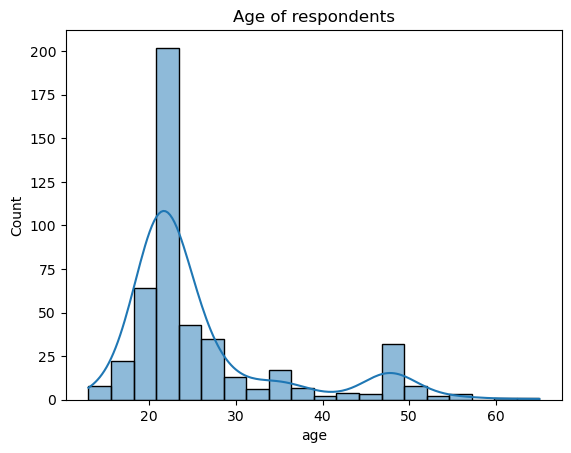

In [76]:
print(df['gender'].value_counts())        # 0 = Female, 1 = Male
print(df[['Student', 'Retired']].sum())   # career one-hots
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age of respondents')
plt.show()

**Q2. Which platforms are most used?**

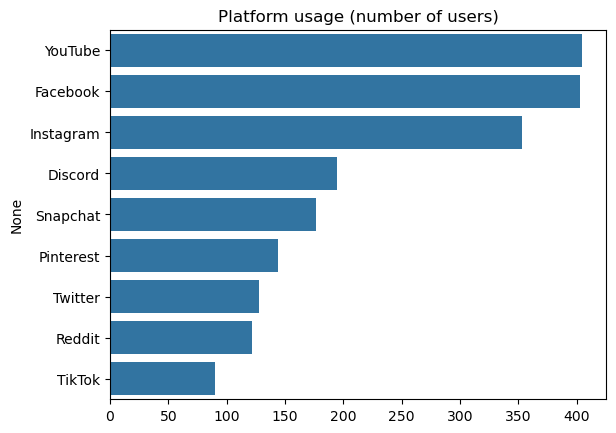

In [77]:
platforms = ['Discord', 'Facebook', 'Instagram', 'Pinterest', 'Reddit',
             'Snapchat', 'TikTok', 'Twitter', 'YouTube']
counts = df[platforms].sum().sort_values(ascending=False)
sns.barplot(x=counts.values, y=counts.index)
plt.title('Platform usage (number of users)')
plt.show()

**Q3. How long do people spend on social media daily?** (0 = <1h … 5 = >5h)

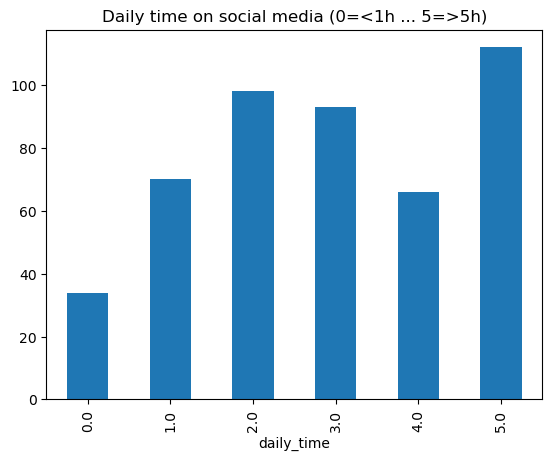

In [78]:
df['daily_time'].value_counts().sort_index().plot(kind='bar')
plt.title('Daily time on social media (0=<1h ... 5=>5h)')
plt.show()

**Q4. Do heavier users report more distress?**

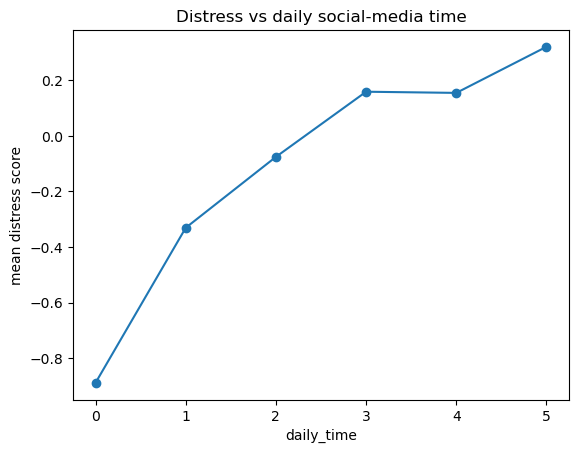

In [79]:
df.groupby('daily_time')['distress_score'].mean().plot(marker='o')
plt.ylabel('mean distress score')
plt.title('Distress vs daily social-media time')
plt.show()

**Q5. Does feeling restless without social media track depression?**

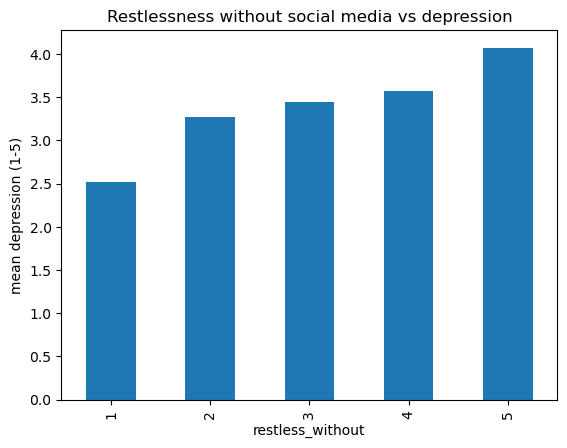

In [80]:
df.groupby('restless_without')['depression'].mean().plot(kind='bar')
plt.ylabel('mean depression (1-5)')
plt.title('Restlessness without social media vs depression')
plt.show()

**Q6. Any gender differences in comparison & validation-seeking?** (0 = Female, 1 = Male)

In [81]:
df.groupby('gender')[['comparison', 'seeks_validation']].mean()

,comparison,seeks_validation
gender,,
0,2.973282,2.496183
1,2.639810,2.383886


**Q7. Which behaviors correlate most with the distress target?**

In [82]:
df[behavior + ['target']].corr()['target'].drop('target').sort_values()

seeks_validation        0.224485
aimless_use             0.328794
daily_time              0.343355
comparison              0.388899
restless_without        0.403827
distracted_when_busy    0.439384
Name: target, dtype: float64

In [83]:
# Predictors = behavior + demographics/platforms.
# (distress items are NOT here -> no leakage into the target)
features = behavior + [
    'age', 'gender', 'Student', 'Retired',
    'Discord', 'Facebook', 'Instagram', 'Pinterest', 'Reddit',
    'Snapchat', 'TikTok', 'Twitter', 'YouTube',
    'rel_Divorced', 'rel_In a relationship', 'rel_Married', 'rel_Single']

In [84]:
X = df[features]
y = df['target']

In [85]:
X_train , X_test , y_train , y_test = train_test_split(
    X,y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 7. Modeling

`Dummy` floor → **Logistic Regression** (primary, interpretable) → **XGBoost** (comparison).
All scored with 5-fold ROC-AUC, then evaluated on the untouched test set.

In [86]:
from sklearn.dummy import DummyClassifier

stkfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
print(f"Baseline (majority-class) test accuracy: {dummy.score(X_test, y_test):.3f}")
print("A baseline's ROC-AUC is 0.5 by definition.")

Baseline (majority-class) test accuracy: 0.505
A baseline's ROC-AUC is 0.5 by definition.


### Logistic Regression — primary model

Scaled features; the coefficients are the deliverable (which behaviors raise distress odds).

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

logreg = make_pipeline(StandardScaler(),
                       LogisticRegression(max_iter=1000, random_state=42))

lr_cv = cross_val_score(logreg, X_train, y_train, cv=stkfold, scoring='roc_auc')
print(f"Logistic Regression CV ROC-AUC: {lr_cv.mean():.3f} +/- {lr_cv.std():.3f}")

logreg.fit(X_train, y_train)

Logistic Regression CV ROC-AUC: 0.818 +/- 0.011


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, random_state=42))])

### XGBoost — comparison (nested CV)

In [88]:
from scipy.stats import randint, loguniform
from xgboost import XGBClassifier

param_dist = {
    'n_estimators':     randint(100, 600),
    'learning_rate':    loguniform(0.01, 0.2),
    'max_depth':        randint(2, 5),
    'min_child_weight': randint(3, 15),
    'reg_alpha':        loguniform(1e-2, 5),
}

xgbc = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)

In [89]:
stkfold =  StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    xgbc, param_dist,
    n_iter=60,
    scoring='roc_auc',
    cv=stkfold,
    random_state=42,
    n_jobs=-1,
    refit=True,
    verbose=0
)
cv_score = cross_val_score(search,X,y,cv=stkfold,scoring='roc_auc')

In [90]:
print("Nested AUC per fold:", cv_score.round(3))
print(f"NESTED AUC (report this): {cv_score.mean():.3f} +/- {cv_score.std():.3f}")

Nested AUC per fold: [0.822 0.778 0.815 0.876 0.835]
NESTED AUC (report this): 0.825 +/- 0.032


In [91]:
search.fit(X, y)
print(f"\nInner-CV best AUC: {search.best_score_:.3f}  <- optimistic, do not report")
print("Best params:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k}: {round(v, 4) if isinstance(v, float) else v}")


Inner-CV best AUC: 0.827  <- optimistic, do not report
Best params:
  learning_rate: 0.0169
  max_depth: 2
  min_child_weight: 6
  n_estimators: 159
  reg_alpha: 0.0506


## 8. Evaluation & Interpretation

Both models scored on the **held-out test set** (never seen during CV/tuning).

In [92]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

xgb_best = search.best_estimator_
xgb_best.fit(X_train, y_train)

for name, model in [('Logistic Regression', logreg), ('XGBoost', xgb_best)]:
    proba = model.predict_proba(X_test)[:, 1]
    print(f"{name:20s} test ROC-AUC: {roc_auc_score(y_test, proba):.3f}")

Logistic Regression  test ROC-AUC: 0.857
XGBoost              test ROC-AUC: 0.846


              precision    recall  f1-score   support

         Low       0.83      0.79      0.81        48
        High       0.80      0.83      0.81        47

    accuracy                           0.81        95
   macro avg       0.81      0.81      0.81        95
weighted avg       0.81      0.81      0.81        95



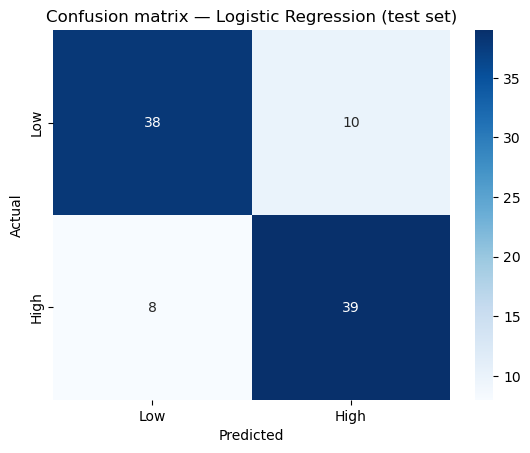

In [93]:
y_pred = logreg.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Low', 'High']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion matrix — Logistic Regression (test set)')
plt.show()

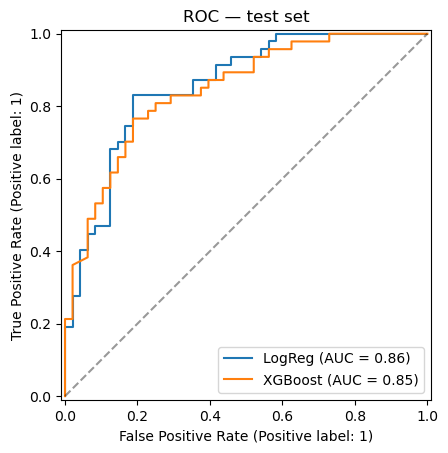

In [ ]:
from sklearn.metrics import RocCurveDisplay

ax = plt.gca()
RocCurveDisplay.from_estimator(logreg, X_test, y_test, name='LogReg', ax=ax)
RocCurveDisplay.from_estimator(xgb_best, X_test, y_test, name='XGBoost', ax=ax)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.title('ROC — test set')
plt.show()

### **Try PCA with models**

In [95]:
from sklearn.decomposition import PCA 
from sklearn.ensemble import GradientBoostingClassifier


In [105]:
pca = PCA(n_components=0.95)
pipe = make_pipeline(
    StandardScaler(),
    pca,
    GradientBoostingClassifier(max_depth=5,max_features='sqrt',random_state=42)

).fit(X_train,y_train)

gbm_pred = pipe.predict(X_test)
gbm_prob = pipe.predict_proba(X_test)[:,1]


In [110]:
pipe.n_features_in_

23

In [112]:
pca.explained_variance_ratio_

array([0.18150284, 0.10989684, 0.08366503, 0.06875163, 0.06159927,
       0.0542961 , 0.04845568, 0.04469505, 0.0397081 , 0.03380767,
       0.03349517, 0.02956868, 0.02726963, 0.02609697, 0.02527575,
       0.02357077, 0.02244696, 0.02173222, 0.02042659])

In [107]:
print(round(accuracy_score(y_test,gbm_pred),3))
print(round(roc_auc_score(y_test,gbm_prob),3))

0.747
0.811


In [118]:
pipe = make_pipeline(
    StandardScaler(),
    pca,
    XGBClassifier(max_depth=5,random_state=42)

).fit(X_train,y_train)

xgb_pred = pipe.predict(X_test)
xgb_prob = pipe.predict_proba(X_test)[:,1]


In [119]:
print(round(accuracy_score(y_test,xgb_pred),3))
print(round(roc_auc_score(y_test,xgb_prob),3))

0.726
0.816


In [120]:
pipe = make_pipeline(
    StandardScaler(),
    pca,
    LogisticRegression(max_iter=1000,random_state=42)

).fit(X_train,y_train)

log_reg_pred = pipe.predict(X_test)
log_reg_prob = pipe.predict_proba(X_test)[:,1]

In [121]:
print(round(accuracy_score(y_test,log_reg_pred),3))
print(round(roc_auc_score(y_test,log_reg_prob),3))

0.8
0.856
